<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/01-PyTorch/03-PyTorch-Object-Detection/01_R_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy
import torch
import os
from detection_utils import intersection_over_union, non_max_suppression

!pip -q install selectivesearch
import selectivesearch
import cv2

  Preparing metadata (setup.py) ... done


In [2]:
import kagglehub
path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

100%|██████████| 1.65G/1.65G [01:07<00:00, 26.4MB/s]

Extracting files...


In [3]:
import os
import xml.etree.ElementTree as ET

annotations_dir = None
images_dir = None

#The dataset is very messy or we are auto finding the folder's or dir's path we needs
for root_dir, dirs, files in os.walk(path):
    if "Annotations" in dirs:
        annotations_dir = os.path.join(root_dir, "Annotations")
    if "JPEGImages" in dirs:
        images_dir = os.path.join(root_dir, "JPEGImages")

if not annotations_dir or not images_dir:
    raise FileNotFoundError("Could not find Annotations or JPEGImages folders in the dataset.")

print(f"Found Annotations at: {annotations_dir}")
print(f"Found Images at: {images_dir}")
print("-" * 50)

#Extracting only the three classes for this small experiment
target_classes = {"person", "dog", "car"}
filtered_dataset = []

for xml_filename in os.listdir(annotations_dir):
    if not xml_filename.endswith(".xml"):
        continue

    xml_path = os.path.join(annotations_dir, xml_filename)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(images_dir, filename)

    target_objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name in target_classes:
            bndbox = obj.find("bndbox")
            xmin = int(float(bndbox.find("xmin").text))
            ymin = int(float(bndbox.find("ymin").text))
            xmax = int(float(bndbox.find("xmax").text))
            ymax = int(float(bndbox.find("ymax").text))

            target_objects.append({
                "class_name": class_name,
                "bbox": [xmin, ymin, xmax, ymax]
            })

    if len(target_objects) > 0:
        filtered_dataset.append({
            "image_path": image_path,
            "objects": target_objects
        })

print(f"Successfully processed {len(filtered_dataset)} images containing a person, dog, or car.")
print(f"Sample data: {filtered_dataset[0]}")

Found Annotations at: /root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctest_06-nov-2007/VOCdevkit/VOC2007/Annotations
Found Images at: /root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctest_06-nov-2007/VOCdevkit/VOC2007/JPEGImages
--------------------------------------------------
Successfully processed 2895 images containing a person, dog, or car.
Sample data: {'image_path': '/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctest_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/006370.jpg', 'objects': [{'class_name': 'person', 'bbox': [161, 119, 234, 427]}, {'class_name': 'person', 'bbox': [262, 159, 276, 188]}, {'class_name': 'person', 'bbox': [347, 161, 357, 189]}, {'class_name': 'person', 'bbox': [356, 162, 367, 190]}, {'class_name': 'person', 'bbox': [234, 160, 251, 185]}, {'class_name': 'person', 'bbox': [32, 152, 46, 181]}, {'class_name': 'person', 'bbox': [54, 155, 67, 183]}, {'class_name': 'person', 'bbox': [103, 167, 110, 181]

In [4]:
#While this code did work it just that we don't be able to show it the way i wanted it to be that is 4*4 grid of 16 image

#Randomly picking 16 images with ground truth box for visuallization
# import random
# from google.colab.patches import cv2_imshow

# Loop for puting the box and class name on the img
# for i in range(16):
#   random_idx=random.randint(0,len(filtered_dataset))
#   img=cv2.imread(filtered_dataset[random_idx]["image_path"])
#   for obj in filtered_dataset[random_idx]["objects"]:
#     class_name = obj["class_name"]
#     bbox = obj["bbox"]
#     cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
#     cv2.putText(img, class_name, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

#   cv2_imshow(img)
#   cv2.waitKey(0)
#   cv2.destroyAllWindows()

<Figure size 1000x1000 with 0 Axes>

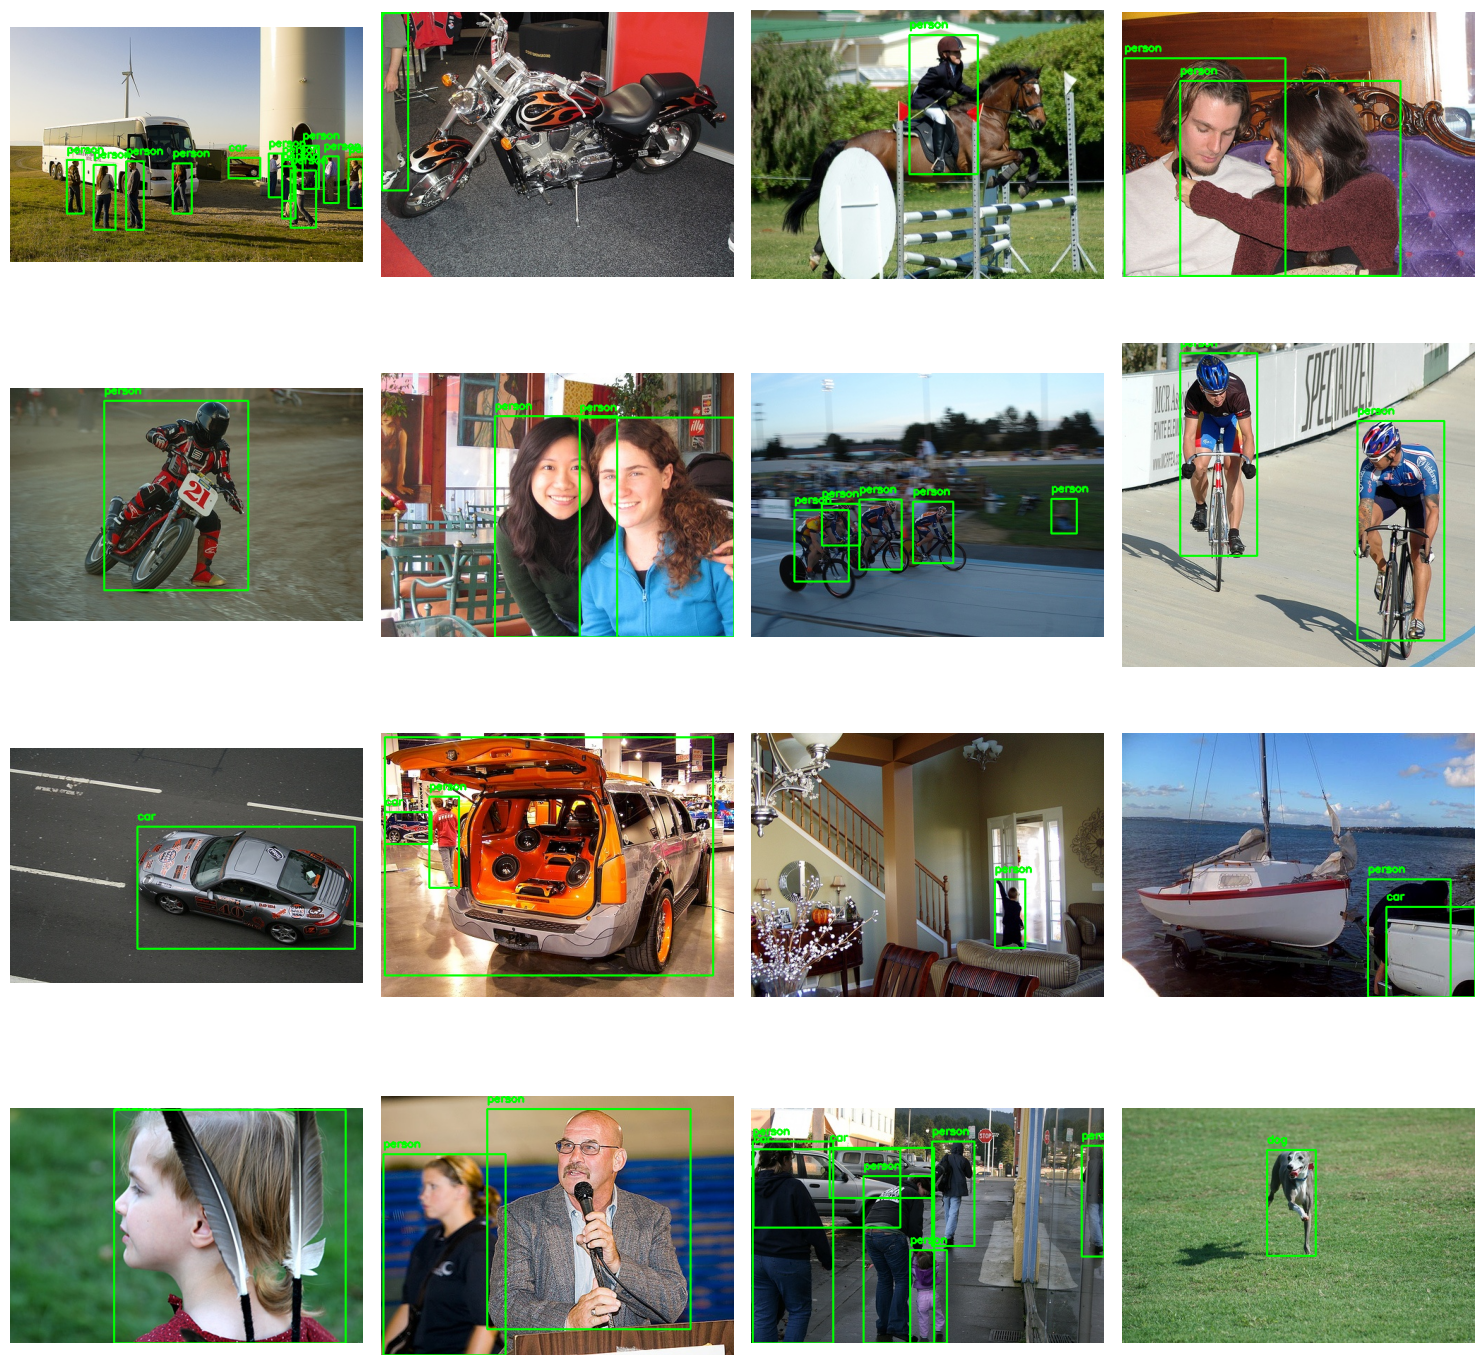

In [5]:
import random
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 10))

sample_indices = random.sample(range(len(filtered_dataset)), 16) # Using the random.sample rather than randint for 16 unique indices

# Create a 4x4 grid for plot
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

#Adding all the ground truth boxes for each img for visualization
for idx, ax in zip(sample_indices, axes):
    img = cv2.imread(filtered_dataset[idx]["image_path"])

    for obj in filtered_dataset[idx]["objects"]:
        class_name = obj["class_name"]
        bbox = obj["bbox"]

        cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
        cv2.putText(img, class_name, (bbox[0], max(0, bbox[1] - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.axis("off")

plt.tight_layout()

sns.despine()
plt.show()

In [6]:
def extract_proposals(images,max_proposals=2000):
  '''
     images: cv2 images(H,W,C)
     max_proposals: int (max proposals per image default=2000)
  '''
  _,regions=selectivesearch.selective_search(images,scale=500,sigma=0.9,min_size=10)

  proposals=[]
  for r in regions:
    if r['rect'] == (0,0,images.shape[1],images.shape[0]):
      continue

    x,y,w,h=r['rect']
    if w>0 and h>0:
      proposals.append([x,y,x+w,y+h])

  proposals=list(set(tuple(x) for x in proposals))
  proposals=proposals[:max_proposals]

  return proposals[:max_proposals]

#### Saving a json file
This rcnn_proposals_data will contain the image path , seleative search proposals and ground truth.
* image_path
* croped_boxs
* ground_truth

In [ ]:
#proposal boxes and ground truth with img_path to a json file
import json

all_data=[]
output_file="rcnn_proposals_data.json"

for i in range(0,len(filtered_dataset)):
  img_path=filtered_dataset[i]["image_path"]
  img=cv2.imread(img_path)
  if img is None:
    continue

  croped_boxs= extract_proposals(img, max_proposals=500)

  all_data.append({
                  "image_path":img_path,
                  "croped_boxs":croped_boxs,
                  "ground_truth":filtered_dataset[i]["objects"]
                  })
  if (i + 1) % 25 == 0 or (i + 1) == len(filtered_dataset):
        print(f"Processed {i + 1}/{len(filtered_dataset)} images")

        with open(output_file, "w") as f:
            json.dump(all_data, f)

print(f"Successfully saved proposal data to {output_file}")

Processed 25/2878 images
Processed 50/2878 images
Processed 75/2878 images
Processed 100/2878 images
Processed 125/2878 images
Processed 150/2878 images
Processed 175/2878 images
Processed 200/2878 images
Processed 225/2878 images
Processed 250/2878 images
Processed 275/2878 images
Processed 300/2878 images
Processed 325/2878 images
Processed 350/2878 images
Processed 375/2878 images
Processed 400/2878 images
Processed 425/2878 images
Processed 450/2878 images
Processed 475/2878 images
Processed 500/2878 images
Processed 525/2878 images
Processed 550/2878 images
Processed 575/2878 images
Processed 600/2878 images
Processed 625/2878 images
Processed 650/2878 images
Processed 675/2878 images
Processed 700/2878 images
Processed 725/2878 images
Processed 750/2878 images
Processed 775/2878 images
Processed 800/2878 images
Processed 825/2878 images
Processed 850/2878 images
Processed 875/2878 images
Processed 900/2878 images
Processed 925/2878 images
Processed 950/2878 images
Processed 975/2

In [15]:
import torch.nn as nn
import torchvision.models as model

resnet18=model.resnet18(weights=model.ResNet18_Weights.DEFAULT)
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1])

In [16]:
feature_extractor

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [19]:
class RCNN(nn.Module):
  def __init__(self,feature_extractor,num_classes):
    super(RCNN,self).__init__()
    self.feature_extractor=feature_extractor
    #Classifier block
    self.Classifier=nn.Sequential(
                                  nn.Linear(512,256),
                                  nn.ReLU(),
                                  nn.Dropout(0.3,inplace=False),
                                  nn.Linear(256,128),
                                  nn.ReLU(),
                                  nn.Dropout(0.3,inplace=False),
                                  nn.Linear(128,num_classes)
                                  )
    #Bbox block
    self.Bbox=nn.Sequential(
                            nn.Linear(512,256),
                            nn.ReLU(),
                            nn.Dropout(0.2),
                            nn.Linear(256,128),
                            nn.ReLU(),
                            nn.Dropout(0.2),
                            nn.Linear(128,4)
                            )
  def forward(self,x):
    features=self.feature_extractor(x)
    features=nn.Flatten(features)

    class_scores=self.Classifier(features)
    bbox_offset=self.Bbox(features)

    return class_scores,bbox_offset

In [32]:
def bbox_delta(ground_truth,proposals):
  #For bbox_delta (x,y,w,h) is needed we have (x1,y1,x2,y2) so converting it.
  x1,y1,x2,y2=ground_truth
  xp1,yp1,xp2,yp2=proposals

  xg=(x1+x2)/2
  yg=(y1+y2)/2
  wg=x2-x1
  hg=y2-y1

  xp=(xp1+xp2)/2
  yp=(yp1+yp2)/2
  wp=xp2-xp1
  hp=yp2-yp1

  tx=(xg-xp)/wp
  ty=(yg-yp)/hp
  tw=torch.log(wg/wp)
  th=torch.log(hg/hp)

  bbox_delta=torch.stack([tx,ty,tw,th])

  return bbox_delta

def bbox_delta_to_box(bbox_delta,proposals):
  xp1,yp1,xp2,yp2=proposals
  tx,ty,tw,th=bbox_delta

  xp=(xp1+xp2)/2
  yp=(yp1+yp2)/2
  wp=xp2-xp1
  hp=yp2-yp1

  w=wp*torch.exp(tw)
  h=hp*torch.exp(th)

  x=xp+tx*wp
  y=yp+ty*hp

  box=torch.stack([x,y,w,h])
  refined_box=torch.stack([x-w/2,y-h/2,x+w/2,y+h/2])

  return box,refined_box


In [33]:
#Checking the math of bbox_delta and bbox_delta_to_box
a=torch.tensor([23,43,28,49])
b=torch.tensor([26,30,33,40])
delta=bbox_delta(a,b)
print(f"So the bbox_delta is {delta}")
box,refined_box=bbox_delta_to_box(delta,b)
print(f"So the bbox_delta_to_box(x,y,w,h) is {box}")
print(f"So the refined_box is {refined_box}")

So the bbox_delta is tensor([-0.5714,  1.1000, -0.3365, -0.5108])
So the bbox_delta_to_box(x,y,w,h) is tensor([25.5000, 46.0000,  5.0000,  6.0000])
So the refined_box is tensor([23., 43., 28., 49.])
